# Group06 — Malevis — Task 1: Image EDA

**Track:** Custom CNN + Attention<br>
**Dataset:** Malevis<br>
**Problem:** Multiclass malware-family classification from RGB byte images with redundant byte-image mitigation

In [1]:
!unzip -q "archive (1).zip" -d "malevis_dataset"

unzip:  cannot find or open archive (1).zip, archive (1).zip.zip or archive (1).zip.ZIP.


In [2]:
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_106beb31ca182436bb9bdc9b8c3916ab"

!kaggle datasets download -d sohamkumar1703/malevis-dataset

!unzip -q malevis-dataset.zip -d malevis_dataset

!rm malevis-dataset.zip
print("Dataset downloaded and unzipped successfully!")


Dataset URL: https://www.kaggle.com/datasets/sohamkumar1703/malevis-dataset
License(s): unknown
100% 2.92G/2.92G [00:29<00:00, 106MB/s]

replace malevis_dataset/malevis_train_val_300x300/train/Adposhel/010e3d42f4a163706efb4a3f3c8e0f780d05621bresized_image.png? [y]es, [n]o, [A]ll, [N]one, [r]ename: Dataset downloaded and unzipped successfully!


In [3]:
from pathlib import Path

candidate_paths = [
    Path("./malevis_dataset/malevis_train_val_300x300"),
    Path("./malevis_dataset"),
    Path("./")
]

DATASET_PATH = None

for candidate in candidate_paths:
    if (candidate / "train").exists() and (candidate / "val").exists():
        DATASET_PATH = candidate
        break

if DATASET_PATH is None:
    matches = [p.parent for p in Path(".").rglob("train") if p.parent.name == "malevis_dataset" or p.parent.exists()]
    if matches:
        DATASET_PATH = matches[0]

if DATASET_PATH is None:
    raise FileNotFoundError(
        "Could not locate the extracted MaleVis folders locally in Colab. "
        "Make sure the Kaggle download and unzip commands completed without errors."
    )

print("Dataset located at:")
print(DATASET_PATH.resolve())

Dataset located at:
/content/malevis_dataset/malevis_train_val_300x300


## Cell 1 — Import libraries

In [1]:
import os
import math
import hashlib
import warnings
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm.auto import tqdm
from IPython.display import display

import plotly.express as px
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Libraries imported successfully.")

Libraries imported successfully.


## Cell 2 — Configuration

In [3]:
from pathlib import Path

DATASET_NAME = "Malevis"
DATASET_SOURCE = "Kaggle"
PROJECT_TRACK = "Custom CNN + Attention"
PROBLEM_TYPE = "Multiclass Malware Family Classification"

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}

MAX_PIXEL_SAMPLE_IMAGES = 500
MAX_PIXELS_PER_IMAGE = 5000

OUTPUT_DIR = Path("./Group06_Malevis_Task1")
FIGURE_DIR = OUTPUT_DIR / "figures"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR)

Output directory: Group06_Malevis_Task1


## Cell 3 — Locate the dataset automatically

In [5]:
candidate_paths = [
    Path("./malevis_dataset/malevis_train_val_300x300"),
    Path("./malevis_dataset")
]

DATASET_PATH = None

for candidate in candidate_paths:
    if candidate.exists():
        DATASET_PATH = candidate
        break

if DATASET_PATH is None:
    matches = list(Path(".").rglob("malevis_train_val_300x300"))
    if matches:
        DATASET_PATH = matches[0]

if DATASET_PATH is None:
    raise FileNotFoundError(
        "Could not locate 'malevis_train_val_300x300'. "
        "Make sure you uploaded 'archive (1).zip' to Colab and ran the unzip command cell."
    )

print("Dataset located at:")
print(DATASET_PATH)

Dataset located at:
malevis_dataset/malevis_train_val_300x300


## Cell 4 — Build the image dataframe

In [7]:
import pandas as pd

records = []

subdirs = [DATASET_PATH / "train", DATASET_PATH / "val"]

for subdir in subdirs:
    if not subdir.exists():
        continue

    class_directories = sorted(
        [folder for folder in subdir.iterdir() if folder.is_dir()],
        key=lambda p: p.name.lower()
    )

    for class_dir in class_directories:
        for file_path in sorted(class_dir.rglob("*")):
            if file_path.is_file() and file_path.suffix.lower() in IMAGE_EXTENSIONS:
                records.append({
                    "Image_Path": str(file_path),
                    "File_Name": file_path.name,
                    "Class": class_dir.name,
                    "Split": subdir.name
                })

df = pd.DataFrame(records)

if df.empty:
    raise RuntimeError("No supported image files were found. Check your unzip path.")

print(f"Total images found : {len(df):,}")
print(f"Total classes      : {df['Class'].nunique()}")
display(df.head())

Total images found : 14,226
Total classes      : 26


,Image_Path,File_Name,Class,Split
0,malevis_dataset/malevis_train_val_300x300/trai...,010e3d42f4a163706efb4a3f3c8e0f780d05621bresize...,Adposhel,train
1,malevis_dataset/malevis_train_val_300x300/trai...,01164710189f86ca25cb99cab3e060d9d417c787resize...,Adposhel,train
2,malevis_dataset/malevis_train_val_300x300/trai...,013381e81ff10e541fb0750e11dcc4a85b558b5dresize...,Adposhel,train
3,malevis_dataset/malevis_train_val_300x300/trai...,01ec973597a667f17a2e9a1142e498f3176e7578resize...,Adposhel,train
4,malevis_dataset/malevis_train_val_300x300/trai...,04028a976dfcfb040a6238dc37bef7ab85a6f606resize...,Adposhel,train


# A. Dataset Summary

## Cell 5 — Validate images and extract metadata

In [8]:
import numpy as np
import cv2
import os
from PIL import Image
from tqdm.auto import tqdm
import pandas as pd
from pathlib import Path

def calculate_entropy(gray_image: np.ndarray) -> float:
    histogram = cv2.calcHist(
        [gray_image], [0], None, [256], [0, 256]
    ).ravel()

    total = histogram.sum()
    if total == 0:
        return 0.0

    probabilities = histogram / total
    probabilities = probabilities[probabilities > 0]

    return float(-(probabilities * np.log2(probabilities)).sum())

metadata_records = []
corrupt_records = []

for row in tqdm(df.itertuples(index=False), total=len(df), desc="Reading images"):
    path = row.Image_Path

    try:
        with Image.open(path) as pil_image:
            width, height = pil_image.size
            image_format = (
                pil_image.format
                or Path(path).suffix.replace(".", "").upper()
            )
            image_mode = pil_image.mode
            channels = len(pil_image.getbands())

        gray = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

        if gray is None:
            raise ValueError("OpenCV could not decode this image.")

        metadata_records.append({
            "Image_Path": path,
            "Width": width,
            "Height": height,
            "Aspect_Ratio": width / height if height else np.nan,
            "Resolution": f"{width} x {height}",
            "Format": image_format,
            "Mode": image_mode,
            "Channels": channels,
            "File_Size_KB": os.path.getsize(path) / 1024,
            "Brightness": float(np.mean(gray)),
            "Contrast": float(np.std(gray)),
            "Blur_Score": float(
                cv2.Laplacian(gray, cv2.CV_64F).var()
            ),
            "Entropy": calculate_entropy(gray),
            "Readable": True
        })

    except Exception as error:
        corrupt_records.append({
            "Image_Path": path,
            "Error": str(error)
        })

metadata_df = pd.DataFrame(metadata_records)
corrupt_df = pd.DataFrame(corrupt_records)

df = df.merge(metadata_df, on="Image_Path", how="left")
df["Readable"] = df["Readable"].fillna(False)

print(f"Readable images : {int(df['Readable'].sum()):,}")
print(f"Corrupt images  : {len(corrupt_df):,}")

if not corrupt_df.empty:
    display(corrupt_df.head())

Reading images:   0%|          | 0/14226 [00:00<?, ?it/s]

Readable images : 14,226
Corrupt images  : 0


## Cell 6 — Exclude unreadable files from numerical analysis

In [9]:
analysis_df = df[df["Readable"]].copy().reset_index(drop=True)

print(f"Images retained for EDA: {len(analysis_df):,}")
print(f"Images excluded        : {len(df) - len(analysis_df):,}")

Images retained for EDA: 14,226
Images excluded        : 0


## Cell 7 — Main dataset summary table

In [10]:
dataset_summary = pd.DataFrame({
    "Item": [
        "Dataset",
        "Source",
        "Domain",
        "Task",
        "Track",
        "Total images",
        "Readable images",
        "Corrupt images",
        "Number of classes",
        "Dominant format",
        "Dominant channel count",
        "Minimum width",
        "Maximum width",
        "Minimum height",
        "Maximum height"
    ],
    "Value": [
        DATASET_NAME,
        DATASET_SOURCE,
        "Cybersecurity",
        PROBLEM_TYPE,
        PROJECT_TRACK,
        f"{len(df):,}",
        f"{len(analysis_df):,}",
        f"{len(corrupt_df):,}",
        analysis_df["Class"].nunique(),
        analysis_df["Format"].mode().iloc[0],
        int(analysis_df["Channels"].mode().iloc[0]),
        int(analysis_df["Width"].min()),
        int(analysis_df["Width"].max()),
        int(analysis_df["Height"].min()),
        int(analysis_df["Height"].max())
    ]
})

display(dataset_summary)

,Item,Value
0,Dataset,Malevis
1,Source,Kaggle
2,Domain,Cybersecurity
3,Task,Multiclass Malware Family Classification
4,Track,Custom CNN + Attention
5,Total images,"14,226"
6,Readable images,"14,226"
7,Corrupt images,0
8,Number of classes,26
9,Dominant format,PNG


# B. Class Balance

## Cell 8 — Class counts and percentages

In [11]:
class_distribution = (
    analysis_df["Class"]
    .value_counts()
    .rename_axis("Class")
    .reset_index(name="Image_Count")
)

class_distribution["Percentage"] = (
    class_distribution["Image_Count"]
    / class_distribution["Image_Count"].sum()
    * 100
).round(2)

majority_row = class_distribution.iloc[0]
minority_row = class_distribution.iloc[-1]

majority_to_minority_ratio = (
    majority_row["Image_Count"] / minority_row["Image_Count"]
)

print(f"Majority class : {majority_row['Class']} ({majority_row['Image_Count']:,})")
print(f"Minority class : {minority_row['Class']} ({minority_row['Image_Count']:,})")
print(f"Majority-to-minority ratio: {majority_to_minority_ratio:.2f}:1")

display(class_distribution)

Majority class : Other (1,832)
Minority class : Agent (470)
Majority-to-minority ratio: 3.90:1


,Class,Image_Count,Percentage
0,Other,1832,12.88
1,Expiro,501,3.52
2,Elex,500,3.51
3,Snarasite,500,3.51
4,VBA,500,3.51
5,Stantinko,500,3.51
6,Hlux,500,3.51
7,Neoreklami,500,3.51
8,Fasong,500,3.51
9,Androm,500,3.51


## Cell 9 — Static class-distribution plot

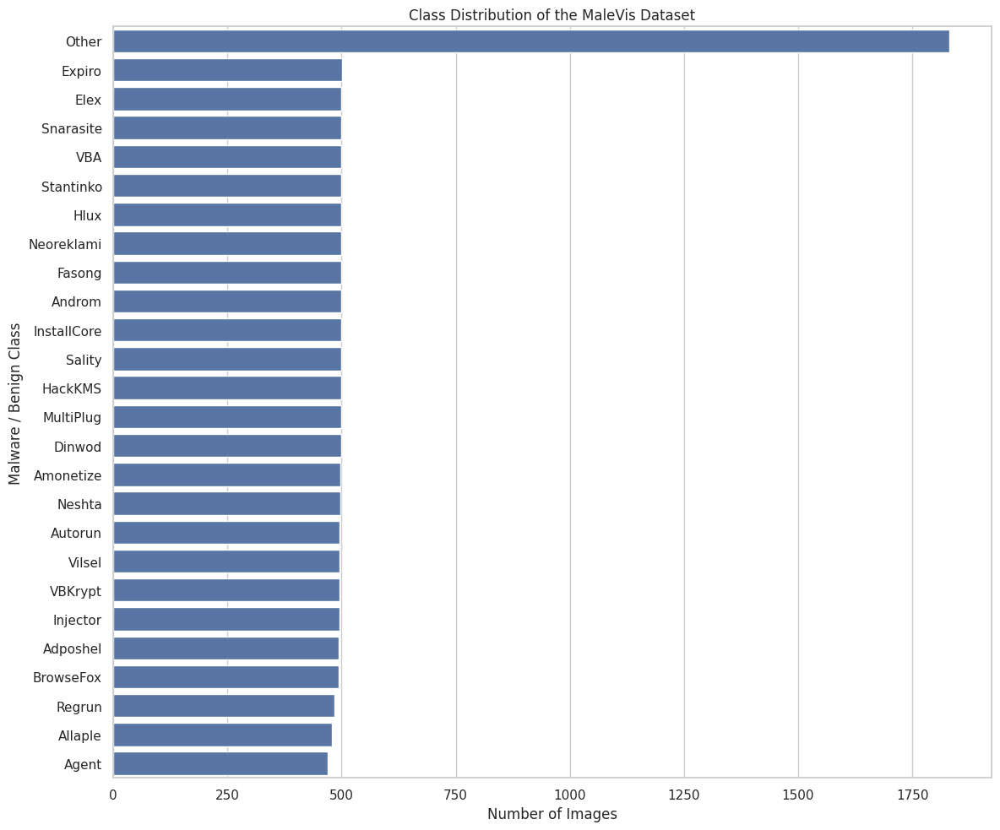

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 10))

sns.barplot(
    data=class_distribution,
    x="Image_Count",
    y="Class"
)

plt.title("Class Distribution of the MaleVis Dataset")
plt.xlabel("Number of Images")
plt.ylabel("Malware / Benign Class")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Cell 10 — Class concentration

In [13]:
concentration_df = class_distribution.copy()
concentration_df["Cumulative_Percentage"] = (
    concentration_df["Percentage"].cumsum()
).round(2)

top_5_share = concentration_df.head(5)["Percentage"].sum()
top_10_share = concentration_df.head(10)["Percentage"].sum()

print(f"Top 5 classes contain  : {top_5_share:.2f}% of all images")
print(f"Top 10 classes contain : {top_10_share:.2f}% of all images")

display(concentration_df)

Top 5 classes contain  : 26.93% of all images
Top 10 classes contain : 44.48% of all images


,Class,Image_Count,Percentage,Cumulative_Percentage
0,Other,1832,12.88,12.88
1,Expiro,501,3.52,16.40
2,Elex,500,3.51,19.91
3,Snarasite,500,3.51,23.42
4,VBA,500,3.51,26.93
5,Stantinko,500,3.51,30.44
6,Hlux,500,3.51,33.95
7,Neoreklami,500,3.51,37.46
8,Fasong,500,3.51,40.97
9,Androm,500,3.51,44.48


# C. Labelled Sample Grid

## Cell 11 — One representative image from every class

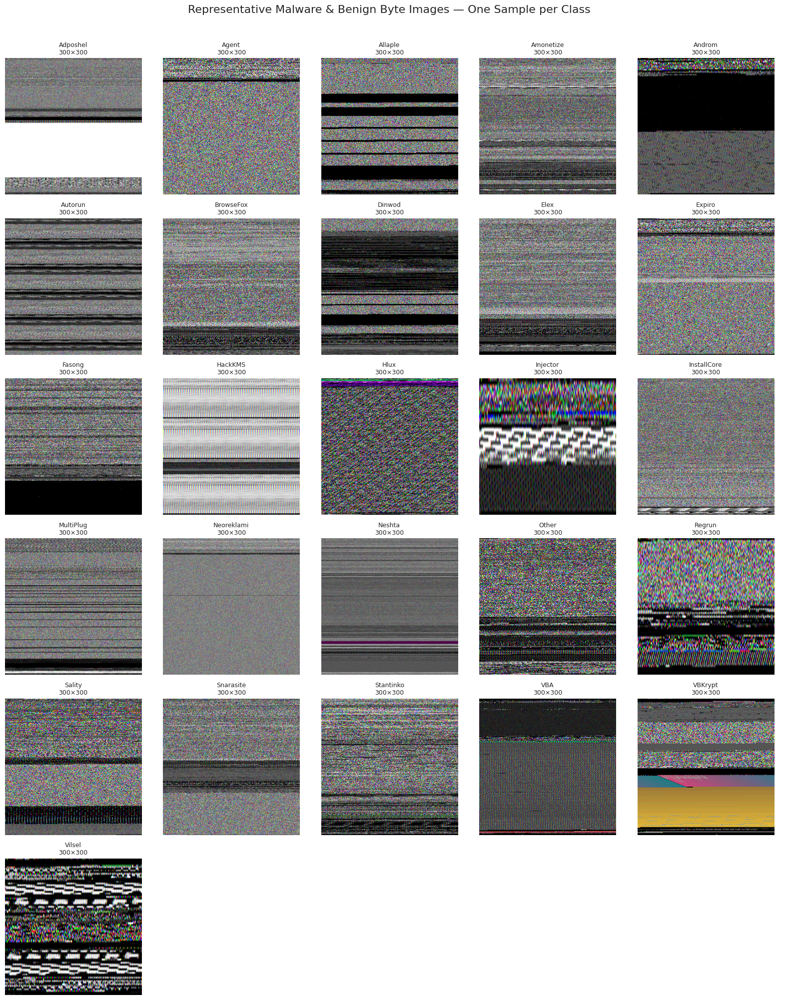

In [14]:
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(analysis_df["Class"].unique())
n_classes = len(classes)

n_cols = 5
n_rows = math.ceil(n_classes / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(16, 3.3 * n_rows)
)

axes = np.array(axes).reshape(-1)

for axis, class_name in zip(axes, classes):
    sample_row = (
        analysis_df[analysis_df["Class"] == class_name]
        .sample(1, random_state=SEED)
        .iloc[0]
    )

    image = Image.open(sample_row["Image_Path"])

    axis.imshow(image)
    axis.set_title(
        f"{class_name}\n"
        f"{sample_row['Width']}×{sample_row['Height']}",
        fontsize=9
    )
    axis.axis("off")

for axis in axes[n_classes:]:
    axis.axis("off")

fig.suptitle(
    "Representative Malware & Benign Byte Images — One Sample per Class",
    fontsize=16,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "sample_grid_all_classes.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Cell 12 — Within-class visual variation

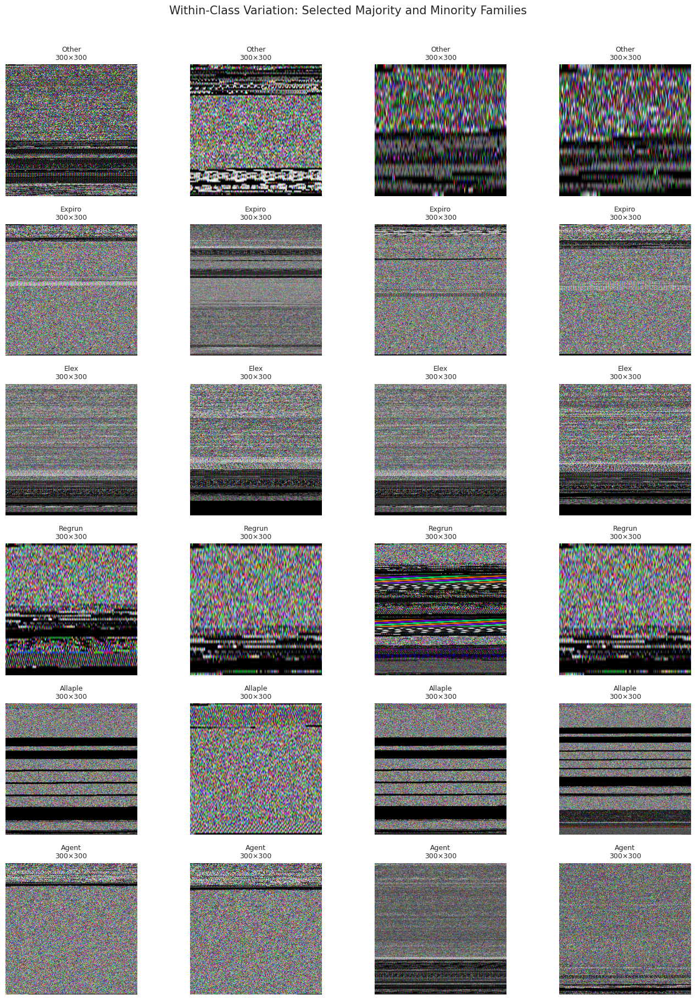

In [15]:
import matplotlib.pyplot as plt
from PIL import Image

selected_classes = (
    list(class_distribution.head(3)["Class"])
    + list(class_distribution.tail(3)["Class"])
)

samples_per_class = 4

fig, axes = plt.subplots(
    len(selected_classes),
    samples_per_class,
    figsize=(14, 3 * len(selected_classes))
)

for row_index, class_name in enumerate(selected_classes):
    class_rows = analysis_df[analysis_df["Class"] == class_name]

    sample_count = min(samples_per_class, len(class_rows))
    sampled_rows = class_rows.sample(
        sample_count,
        random_state=SEED
    )

    for column_index in range(samples_per_class):
        axis = axes[row_index, column_index]

        if column_index < sample_count:
            sample = sampled_rows.iloc[column_index]
            image = Image.open(sample["Image_Path"])

            axis.imshow(image)
            axis.set_title(
                f"{class_name}\n"
                f"{sample['Width']}×{sample['Height']}",
                fontsize=9
            )

        axis.axis("off")

plt.suptitle(
    "Within-Class Variation: Selected Majority and Minority Families",
    fontsize=15,
    y=1.01
)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "within_class_variation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# D. Image Size and Resolution

## Cell 13 — Dimension statistics

In [16]:
dimension_columns = [
    "Width",
    "Height",
    "Aspect_Ratio",
    "File_Size_KB"
]

dimension_summary = analysis_df[dimension_columns].describe().T
dimension_summary["median"] = analysis_df[dimension_columns].median()
dimension_summary["skewness"] = analysis_df[dimension_columns].skew()
dimension_summary["kurtosis"] = analysis_df[dimension_columns].kurt()

display(dimension_summary.round(3))

,count,mean,std,min,25%,50%,75%,max,median,skewness,kurtosis
Width,14226.0,300.000,0.000,300.00,300.000,300.000,300.000,300.000,300.000,0.000,0.000
Height,14226.0,300.000,0.000,300.00,300.000,300.000,300.000,300.000,300.000,0.000,0.000
Aspect_Ratio,14226.0,1.000,0.000,1.00,1.000,1.000,1.000,1.000,1.000,0.000,0.000
File_Size_KB,14226.0,215.199,49.368,4.51,197.172,232.678,249.928,264.101,232.678,-1.804,3.472


## Cell 14 — Most common resolutions

In [17]:
resolution_table = (
    analysis_df["Resolution"]
    .value_counts()
    .rename_axis("Resolution")
    .reset_index(name="Image_Count")
)

resolution_table["Percentage"] = (
    resolution_table["Image_Count"]
    / resolution_table["Image_Count"].sum()
    * 100
).round(2)

print(f"Number of unique resolutions: {len(resolution_table):,}")
display(resolution_table.head(20))

Number of unique resolutions: 1


,Resolution,Image_Count,Percentage
0,300 x 300,14226,100.0


## Cell 15 — Width and height distributions

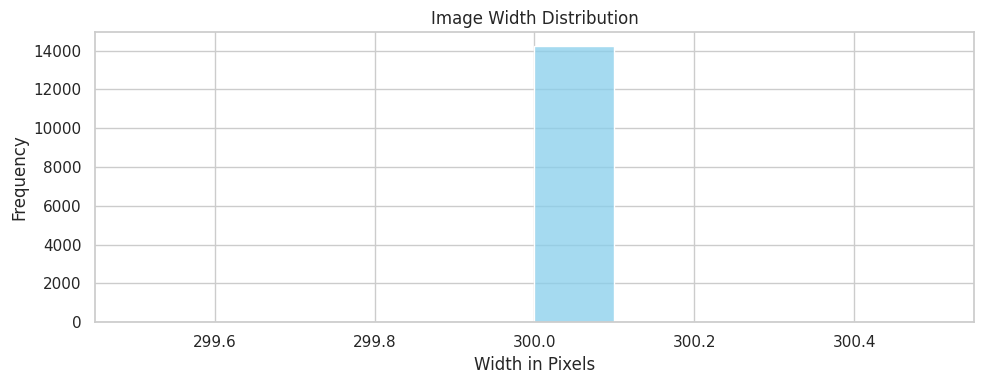

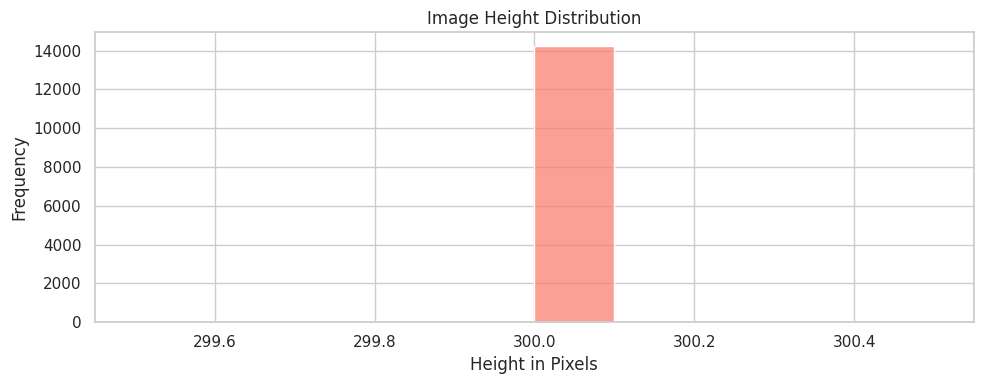

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 4))
sns.histplot(analysis_df["Width"], bins=10, kde=False, color="skyblue")
plt.title("Image Width Distribution")
plt.xlabel("Width in Pixels")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "width_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

plt.figure(figsize=(10, 4))
sns.histplot(analysis_df["Height"], bins=10, kde=False, color="salmon")
plt.title("Image Height Distribution")
plt.xlabel("Height in Pixels")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "height_distribution.png", dpi=300, bbox_inches="tight")
plt.show()

## Cell 16 — Width versus height

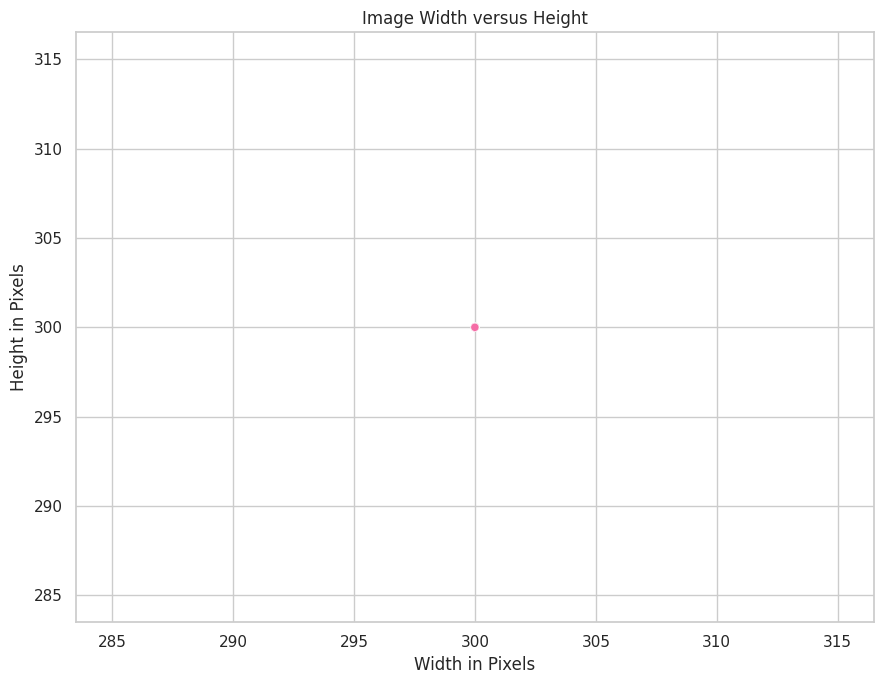

In [19]:
plt.figure(figsize=(9, 7))

sns.scatterplot(
    data=analysis_df,
    x="Width",
    y="Height",
    hue="Class",
    alpha=0.65,
    s=35,
    legend=False
)

plt.title("Image Width versus Height")
plt.xlabel("Width in Pixels")
plt.ylabel("Height in Pixels")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "width_vs_height.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Cell 17 — Aspect-ratio distribution

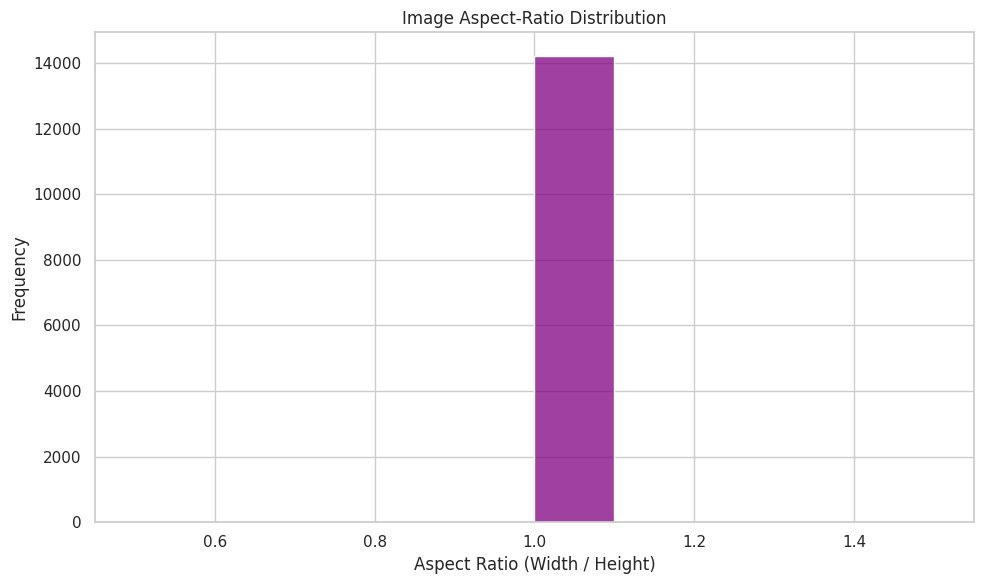

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.histplot(
    analysis_df["Aspect_Ratio"],
    bins=10,
    kde=False,
    color="purple"
)

plt.title("Image Aspect-Ratio Distribution")
plt.xlabel("Aspect Ratio (Width / Height)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "aspect_ratio_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Cell 18 — IQR-based dimension outliers

In [21]:
def iqr_outlier_mask(series: pd.Series) -> pd.Series:
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return (series < lower_bound) | (series > upper_bound)


analysis_df["Width_Outlier"] = iqr_outlier_mask(analysis_df["Width"])
analysis_df["Height_Outlier"] = iqr_outlier_mask(analysis_df["Height"])
analysis_df["Dimension_Outlier"] = (
    analysis_df["Width_Outlier"]
    | analysis_df["Height_Outlier"]
)

dimension_outliers = analysis_df[
    analysis_df["Dimension_Outlier"]
].copy()

print(f"Width outliers        : {analysis_df['Width_Outlier'].sum():,}")
print(f"Height outliers       : {analysis_df['Height_Outlier'].sum():,}")
print(f"Any dimension outlier : {len(dimension_outliers):,}")

display(
    dimension_outliers[
        ["File_Name", "Class", "Width", "Height", "Aspect_Ratio"]
    ].head(20)
)

Width outliers        : 0
Height outliers       : 0
Any dimension outlier : 0


,File_Name,Class,Width,Height,Aspect_Ratio


# E. Pixel and Channel Analysis

## Cell 19 — Formats, modes, and channel counts

In [22]:
format_table = (
    analysis_df["Format"]
    .value_counts()
    .rename_axis("Format")
    .reset_index(name="Image_Count")
)

mode_table = (
    analysis_df["Mode"]
    .value_counts()
    .rename_axis("Mode")
    .reset_index(name="Image_Count")
)

channel_table = (
    analysis_df["Channels"]
    .value_counts()
    .rename_axis("Channels")
    .reset_index(name="Image_Count")
)

print("Image formats")
display(format_table)

print("PIL image modes")
display(mode_table)

print("Channel counts")
display(channel_table)

Image formats


,Format,Image_Count
0,PNG,14226


PIL image modes


,Mode,Image_Count
0,RGB,14226


Channel counts


,Channels,Image_Count
0,3,14226


## Cell 20 — Efficient pixel-intensity sampling

In [23]:
import numpy as np
import cv2
import pandas as pd
from tqdm.auto import tqdm

rng = np.random.default_rng(SEED)

sample_size = min(MAX_PIXEL_SAMPLE_IMAGES, len(analysis_df))

sampled_paths = (
    analysis_df["Image_Path"]
    .sample(sample_size, random_state=SEED)
    .tolist()
)

pixel_samples = []

for path in tqdm(sampled_paths, desc="Sampling pixel intensities"):
    color_img = cv2.imread(path, cv2.IMREAD_COLOR)

    if color_img is None:
        continue

    flattened = color_img.ravel()
    number_to_sample = min(
        MAX_PIXELS_PER_IMAGE,
        len(flattened)
    )

    selected_pixels = rng.choice(
        flattened,
        size=number_to_sample,
        replace=False
    )

    pixel_samples.append(selected_pixels)

pixel_values = np.concatenate(pixel_samples)

pixel_statistics = pd.DataFrame({
    "Statistic": [
        "Sampled images",
        "Sampled pixels",
        "Mean",
        "Median",
        "Standard deviation",
        "Minimum",
        "Q1",
        "Q3",
        "Maximum"
    ],
    "Value": [
        sample_size,
        len(pixel_values),
        pixel_values.mean(),
        np.median(pixel_values),
        pixel_values.std(),
        pixel_values.min(),
        np.percentile(pixel_values, 25),
        np.percentile(pixel_values, 75),
        pixel_values.max()
    ]
})

display(pixel_statistics)

Sampling pixel intensities:   0%|          | 0/500 [00:00<?, ?it/s]

,Statistic,Value
0,Sampled images,5.000000e+02
1,Sampled pixels,2.500000e+06
2,Mean,9.894077e+01
3,Median,1.000000e+02
4,Standard deviation,7.028956e+01
5,Minimum,0.000000e+00
6,Q1,4.100000e+01
7,Q3,1.460000e+02
8,Maximum,2.550000e+02


## Cell 21 — Pixel-intensity histogram

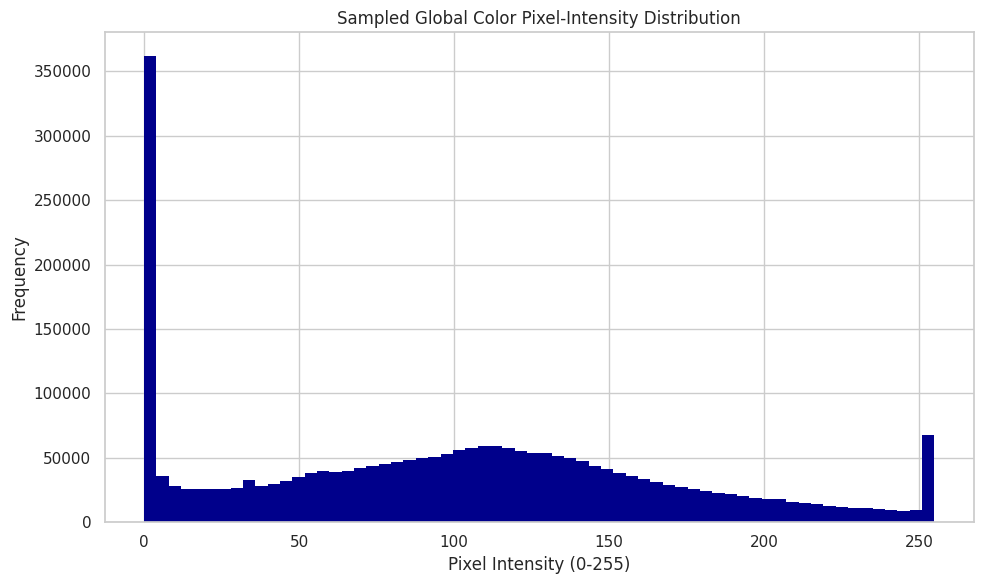

In [24]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.hist(
    pixel_values,
    bins=64,
    color="darkblue",
    edgecolor="none"
)

plt.title("Sampled Global Color Pixel-Intensity Distribution")
plt.xlabel("Pixel Intensity (0-255)")
plt.ylabel("Frequency")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "pixel_intensity_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

## Cell 22 — Mean brightness by class

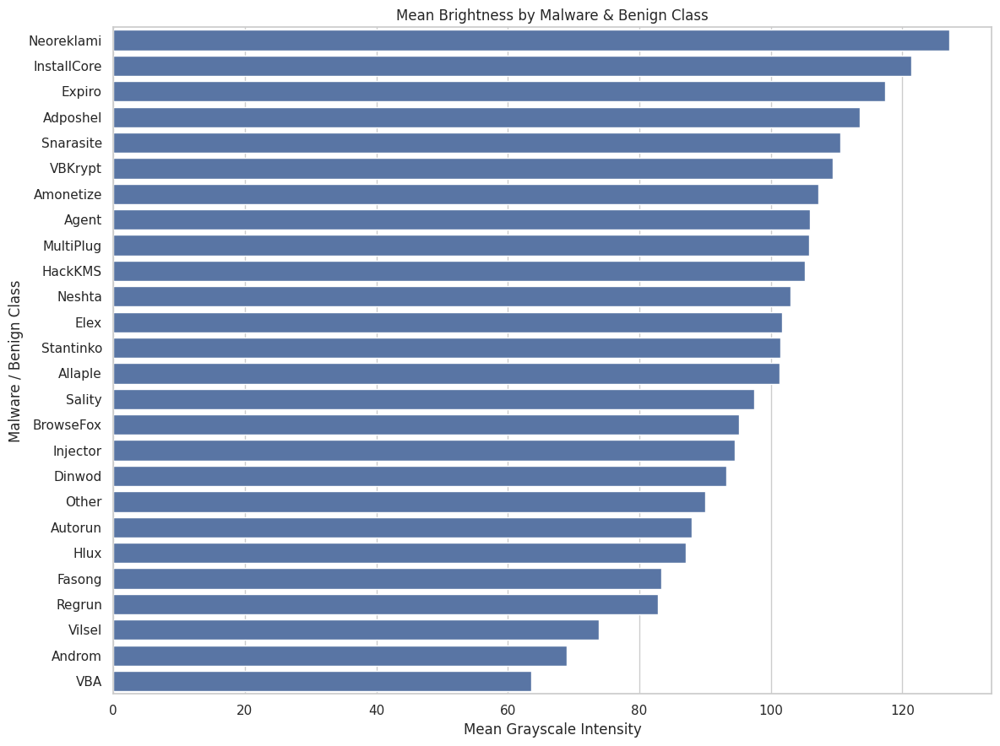

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

class_brightness = (
    analysis_df.groupby("Class", as_index=False)["Brightness"]
    .mean()
    .sort_values("Brightness", ascending=False)
)

plt.figure(figsize=(12, 9))

sns.barplot(
    data=class_brightness,
    x="Brightness",
    y="Class"
)

plt.title("Mean Brightness by Malware & Benign Class")
plt.xlabel("Mean Grayscale Intensity")
plt.ylabel("Malware / Benign Class")
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "mean_brightness_by_class.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# F. Image Quality and Data Quality

## Cell 23 — Overall image-quality statistics

In [26]:
quality_columns = [
    "Brightness",
    "Contrast",
    "Blur_Score",
    "Entropy"
]

quality_summary = analysis_df[quality_columns].describe().T
quality_summary["median"] = analysis_df[quality_columns].median()
quality_summary["skewness"] = analysis_df[quality_columns].skew()

display(quality_summary.round(3))

,count,mean,std,min,25%,50%,75%,max,median,skewness
Brightness,14226.0,97.290,28.541,1.246,81.821,99.684,112.892,226.860,99.684,0.535
Contrast,14226.0,50.505,14.405,4.079,41.732,49.877,60.603,95.005,49.877,-0.309
Blur_Score,14226.0,18416.643,12985.203,70.704,9470.022,16123.541,22267.691,91579.476,16123.541,1.240
Entropy,14226.0,6.965,1.130,0.227,6.850,7.310,7.545,7.944,7.310,-3.091


## Cell 24 — Quality distributions

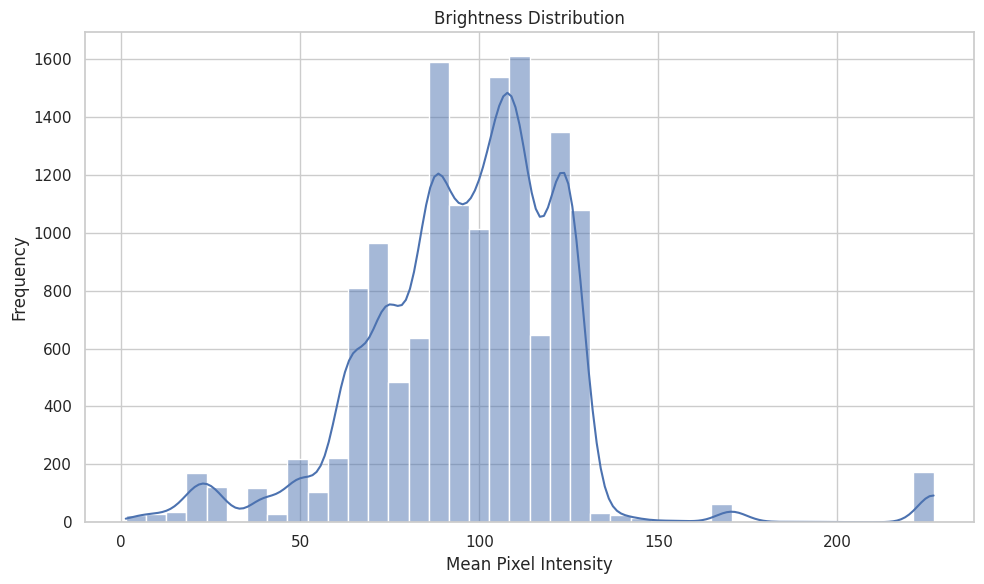

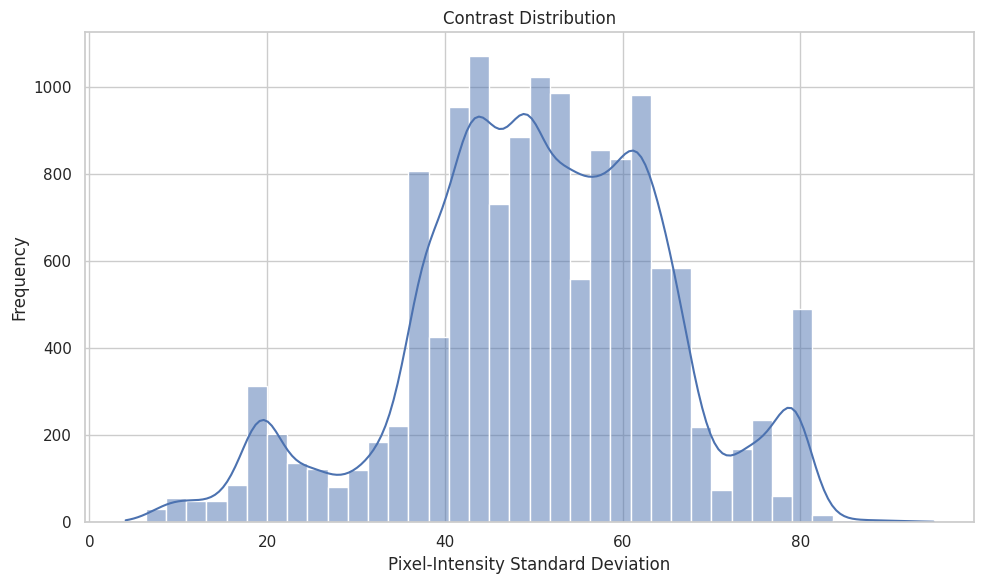

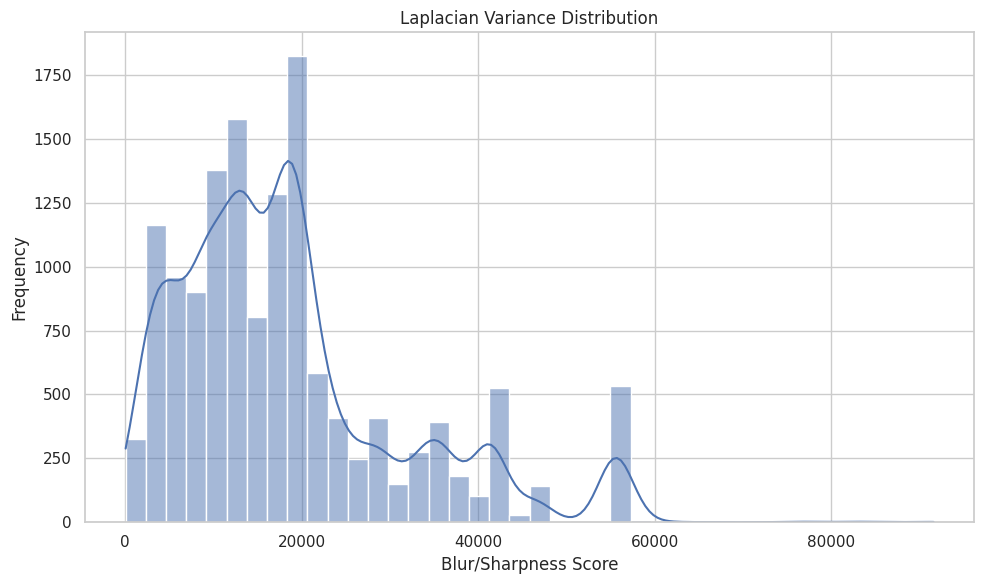

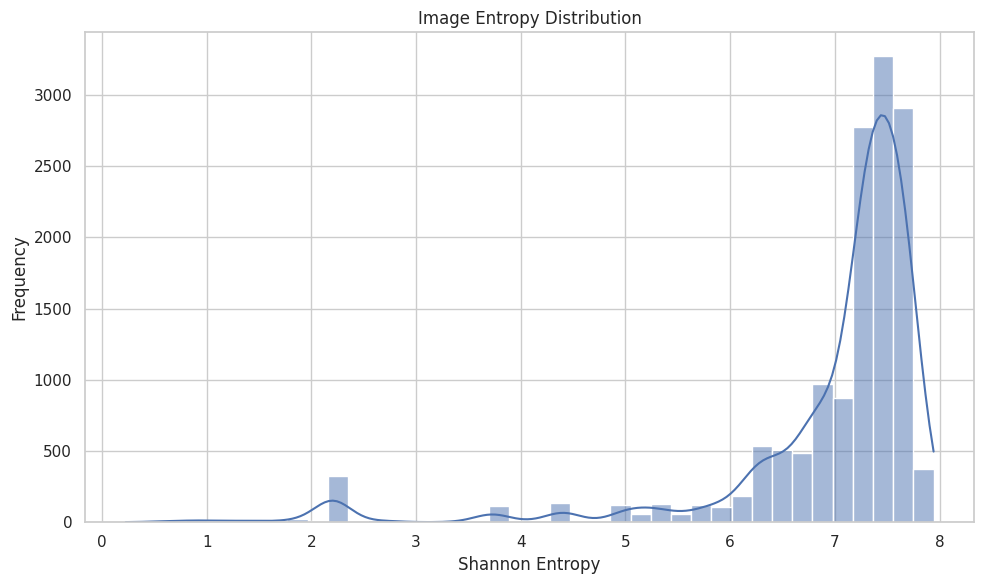

In [27]:
quality_plot_settings = [
    ("Brightness", "Brightness Distribution", "Mean Pixel Intensity"),
    ("Contrast", "Contrast Distribution", "Pixel-Intensity Standard Deviation"),
    ("Blur_Score", "Laplacian Variance Distribution", "Blur/Sharpness Score"),
    ("Entropy", "Image Entropy Distribution", "Shannon Entropy")
]

for column, title, x_label in quality_plot_settings:
    plt.figure(figsize=(10, 6))

    sns.histplot(
        analysis_df[column],
        bins=40,
        kde=True
    )

    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel("Frequency")
    plt.tight_layout()

    plt.savefig(
        FIGURE_DIR / f"{column.lower()}_distribution.png",
        dpi=300,
        bbox_inches="tight"
    )
    plt.show()

## Cell 25 — Per-class quality statistics

In [28]:
class_quality_statistics = (
    analysis_df.groupby("Class")
    .agg(
        Image_Count=("Image_Path", "count"),
        Mean_Width=("Width", "mean"),
        Mean_Height=("Height", "mean"),
        Mean_Aspect_Ratio=("Aspect_Ratio", "mean"),
        Mean_Brightness=("Brightness", "mean"),
        Mean_Contrast=("Contrast", "mean"),
        Mean_Blur_Score=("Blur_Score", "mean"),
        Mean_Entropy=("Entropy", "mean"),
        Mean_File_Size_KB=("File_Size_KB", "mean")
    )
    .round(3)
    .sort_values("Image_Count", ascending=False)
)

display(class_quality_statistics)

,Image_Count,Mean_Width,Mean_Height,Mean_Aspect_Ratio,Mean_Brightness,Mean_Contrast,Mean_Blur_Score,Mean_Entropy,Mean_File_Size_KB
Class,,,,,,,,,
Other,1832,300.0,300.0,1.0,90.050,47.132,13727.328,7.112,211.512
Expiro,501,300.0,300.0,1.0,117.328,45.156,21042.294,7.385,249.924
Elex,500,300.0,300.0,1.0,101.699,53.028,22429.166,7.440,243.728
Snarasite,500,300.0,300.0,1.0,110.574,42.087,18838.799,7.403,256.276
VBA,500,300.0,300.0,1.0,63.601,49.749,55545.664,7.265,181.257
Stantinko,500,300.0,300.0,1.0,101.507,59.650,32173.446,7.675,245.669
Hlux,500,300.0,300.0,1.0,87.076,53.251,41008.697,7.624,247.100
Neoreklami,500,300.0,300.0,1.0,127.198,25.965,10820.266,6.522,238.089
Fasong,500,300.0,300.0,1.0,83.312,61.367,18940.415,6.643,202.813


## Cell 26 — Missing-value and duplicate-row checks

In [29]:
print("Missing values by column")
display(analysis_df.isna().sum().to_frame("Missing_Count"))

print(f"Duplicate dataframe rows: {analysis_df.duplicated().sum():,}")
print(
    "Duplicate image paths:",
    f"{analysis_df.duplicated(subset=['Image_Path']).sum():,}"
)

Missing values by column


,Missing_Count
Image_Path,0
File_Name,0
Class,0
Split,0
Width,0
Height,0
Aspect_Ratio,0
Resolution,0
Format,0
Mode,0


Duplicate dataframe rows: 0
Duplicate image paths: 0


## Cell 27 — Exact duplicate detection with SHA-256

##### Duplicates must be handled before splitting to prevent data leakage.

In [30]:
import hashlib
from tqdm.auto import tqdm

def sha256_file(path: str, chunk_size: int = 1024 * 1024) -> str:
    file_hash = hashlib.sha256()

    with open(path, "rb") as file:
        while True:
            chunk = file.read(chunk_size)

            if not chunk:
                break

            file_hash.update(chunk)

    return file_hash.hexdigest()

analysis_df["Exact_Hash"] = [
    sha256_file(path)
    for path in tqdm(
        analysis_df["Image_Path"],
        desc="Hashing images"
    )
]

analysis_df["Is_Exact_Duplicate"] = analysis_df.duplicated(
    subset=["Exact_Hash"],
    keep=False
)

duplicate_details = (
    analysis_df[analysis_df["Is_Exact_Duplicate"]]
    .sort_values(["Exact_Hash", "Class", "File_Name"])
    .copy()
)

duplicate_images_beyond_first = analysis_df.duplicated(
    subset=["Exact_Hash"],
    keep="first"
).sum()

duplicate_groups = duplicate_details["Exact_Hash"].nunique()

cross_class_duplicate_hashes = (
    duplicate_details.groupby("Exact_Hash")["Class"]
    .nunique()
)

cross_class_duplicate_hashes = cross_class_duplicate_hashes[
    cross_class_duplicate_hashes > 1
]

print(f"Duplicate groups             : {duplicate_groups:,}")
print(f"Duplicate images beyond first: {duplicate_images_beyond_first:,}")
print(f"Cross-class duplicate groups : {len(cross_class_duplicate_hashes):,}")

if not duplicate_details.empty:
    display(
        duplicate_details[
            ["File_Name", "Class", "Resolution", "Exact_Hash"]
        ].head(30)
    )

Hashing images:   0%|          | 0/14226 [00:00<?, ?it/s]

Duplicate groups             : 187
Duplicate images beyond first: 480
Cross-class duplicate groups : 0


,File_Name,Class,Resolution,Exact_Hash
3511,5a7d09748c20d5aaf4692436ef6b92b0bbc5b3earesize...,Fasong,300 x 300,01efba795d273ad40ae8c62723925ae3965b3ea6c4523f...
10588,8590701efa335db27f933ffdeb3c5a0a55fed7f8resize...,Fasong,300 x 300,01efba795d273ad40ae8c62723925ae3965b3ea6c4523f...
1112,24e4dd7bc302f1ef4f3065cec74a0619947c72cdresize...,Amonetize,300 x 300,02bdf40afb932d1337774284ccdc2854068a04ad861ccf...
9628,f92611d8a9257bbfd9d67caf13388f54d6a9d3f5resize...,Amonetize,300 x 300,02bdf40afb932d1337774284ccdc2854068a04ad861ccf...
3609,692e579f864d3a2c5bf0ba7a955ebc3eada344f1resize...,Fasong,300 x 300,04228b469b5f2ffcc192f0f1d1202ecb13c1b3b77557b9...
3715,761ac63ae8f76784c4be49c00eb3a7dc2e751df2resize...,Fasong,300 x 300,04228b469b5f2ffcc192f0f1d1202ecb13c1b3b77557b9...
10624,a5223e47e9c03d97d8935cd4964d7745a22703e5resize...,Fasong,300 x 300,04228b469b5f2ffcc192f0f1d1202ecb13c1b3b77557b9...
1186,4fddfe91f8bb7a31af2da67b524d14dde5e49488resize...,Amonetize,300 x 300,046f3a21c825f319604d6b928e48768597b17ba114e860...
1319,9133f075550994590a9a8b62df124ea478180502resize...,Amonetize,300 x 300,046f3a21c825f319604d6b928e48768597b17ba114e860...
1382,b1a1220fb1ab05bd0febe7a0b52316315b0c7741resize...,Amonetize,300 x 300,046f3a21c825f319604d6b928e48768597b17ba114e860...


## Cell 28 — Inspect cross-class exact duplicates

In [31]:
if len(cross_class_duplicate_hashes) > 0:
    cross_class_duplicates = duplicate_details[
        duplicate_details["Exact_Hash"].isin(
            cross_class_duplicate_hashes.index
        )
    ]

    display(
        cross_class_duplicates[
            ["File_Name", "Class", "Image_Path", "Exact_Hash"]
        ]
    )
else:
    print("No exact duplicate hash was shared by multiple classes.")

No exact duplicate hash was shared by multiple classes.


# G. Interactive Visualizations

## Cell 29 — Interactive class distribution

In [32]:
import plotly.express as px

fig = px.bar(
    class_distribution,
    x="Class",
    y="Image_Count",
    color="Image_Count",
    hover_data=["Percentage"],
    title="Interactive Malware & Benign Class Distribution"
)

fig.update_layout(
    xaxis_title="Malware / Benign Class",
    yaxis_title="Number of Images",
    xaxis_tickangle=-45
)

fig.show()

## Cell 30 — Interactive width versus height

In [33]:
fig = px.scatter(
    analysis_df,
    x="Width",
    y="Height",
    color="Class",
    hover_data=[
        "File_Name",
        "Resolution",
        "Brightness",
        "Contrast",
        "Entropy"
    ],
    title="Interactive Image Width versus Height"
)

fig.show()

## Cell 31 — Interactive image-quality plot

In [34]:
plot_quality_df = analysis_df.copy()
plot_quality_df["Entropy_For_Size"] = (
    plot_quality_df["Entropy"].clip(lower=0.01)
)

fig = px.scatter(
    plot_quality_df,
    x="Brightness",
    y="Contrast",
    color="Class",
    size="Entropy_For_Size",
    hover_data=[
        "File_Name",
        "Width",
        "Height",
        "Blur_Score"
    ],
    title="Interactive Brightness, Contrast, and Entropy Analysis"
)

fig.show()

# Final Task 1 Summary

## Cell 32 — Compact report-ready summary

In [35]:
final_summary = pd.DataFrame({
    "Dataset": [DATASET_NAME],
    "Source": [DATASET_SOURCE],
    "Domain": ["Cybersecurity"],
    "Task": [PROBLEM_TYPE],
    "Total_Images": [len(df)],
    "Readable_Images": [len(analysis_df)],
    "Corrupt_Images": [len(corrupt_df)],
    "Classes": [analysis_df["Class"].nunique()],
    "Majority_Class": [majority_row["Class"]],
    "Majority_Count": [int(majority_row["Image_Count"])],
    "Minority_Class": [minority_row["Class"]],
    "Minority_Count": [int(minority_row["Image_Count"])],
    "Majority_Minority_Ratio": [
        round(majority_to_minority_ratio, 2)
    ],
    "Unique_Resolutions": [
        analysis_df["Resolution"].nunique()
    ],
    "Dominant_Format": [
        analysis_df["Format"].mode().iloc[0]
    ],
    "Dominant_Channels": [
        int(analysis_df["Channels"].mode().iloc[0])
    ],
    "Exact_Duplicate_Groups": [
        int(duplicate_groups)
    ],
    "Duplicate_Images_Beyond_First": [
        int(duplicate_images_beyond_first)
    ],
    "Cross_Class_Duplicate_Groups": [
        int(len(cross_class_duplicate_hashes))
    ],
    "Mean_Width": [
        round(analysis_df["Width"].mean(), 2)
    ],
    "Mean_Height": [
        round(analysis_df["Height"].mean(), 2)
    ],
    "Mean_Brightness": [
        round(analysis_df["Brightness"].mean(), 2)
    ],
    "Mean_Contrast": [
        round(analysis_df["Contrast"].mean(), 2)
    ],
    "Mean_Entropy": [
        round(analysis_df["Entropy"].mean(), 3)
    ]
})

display(final_summary)

,Dataset,Source,Domain,Task,Total_Images,Readable_Images,Corrupt_Images,Classes,Majority_Class,Majority_Count,Minority_Class,Minority_Count,Majority_Minority_Ratio,Unique_Resolutions,Dominant_Format,Dominant_Channels,Exact_Duplicate_Groups,Duplicate_Images_Beyond_First,Cross_Class_Duplicate_Groups,Mean_Width,Mean_Height,Mean_Brightness,Mean_Contrast,Mean_Entropy
0,Malevis,Kaggle,Cybersecurity,Multiclass Malware Family Classification,14226,14226,0,26,Other,1832,Agent,470,3.9,1,PNG,3,187,480,0,300.0,300.0,97.29,50.5,6.965


## Cell 33 — Generate a dynamic report conclusion

In [36]:
channel_statement = (
    "All readable images consistently use 3-channel RGB configurations."
    if analysis_df["Channels"].eq(3).all()
    else f"The dataset contains mixed channel settings: {analysis_df['Channels'].unique()}"
)

imbalance_statement = (
    "The class distribution is strongly imbalanced."
    if majority_to_minority_ratio >= 5
    else "The class distribution shows moderate or low imbalance (well-balanced for training)."
)

resolution_statement = (
    "The images have multiple resolutions, so a consistent resizing strategy will be necessary."
    if analysis_df["Resolution"].nunique() > 1
    else "All images share an identical resolution profile natively."
)

duplicate_statement = (
    f"{duplicate_images_beyond_first} exact duplicate image(s) beyond "
    "the first copy were identified. Duplicate groups must be handled "
    "before splitting to prevent leakage."
    if duplicate_images_beyond_first > 0
    else "No exact duplicate images were detected."
)

conclusion = f'''
TASK 1 EDA CONCLUSION

1. The {DATASET_NAME} dataset contains {len(analysis_df):,} readable images spanning {analysis_df["Class"].nunique()} distinct classes (malware families and benign applications).

2. The largest class is '{majority_row["Class"]}' with {int(majority_row["Image_Count"]):,} images. The smallest class is '{minority_row["Class"]}' with {int(minority_row["Image_Count"]):,} images.

3. The majority-to-minority ratio is {majority_to_minority_ratio:.2f}:1. {imbalance_statement}

4. {channel_statement}

5. The dataset contains {analysis_df["Resolution"].nunique():,} unique resolution(s). {resolution_statement}

6. Structural Texture Statistics: Average brightness is {analysis_df["Brightness"].mean():.2f}, average contrast is {analysis_df["Contrast"].mean():.2f}, and average Shannon entropy is {analysis_df["Entropy"].mean():.3f}.

7. Data Integrity Check: {len(corrupt_df):,} corrupt or unreadable image(s) were detected.

8. Duplication Check: {duplicate_statement}

9. Modeling Preparedness: The dataset is suitable for deep learning pipelines. Task 2 modeling must deploy a leakage-free stratified data partitioning strategy due to the multi-class layout, target normalization, and incorporate attention blocks to manage redundant byte-image regions.

10. XAI Limitations Disclaimer: As specified by course guidelines, standard interpretability tools like Grad-CAM and LIME on malware byte-images yield minimal semantic insights because the structural byte patterns lack spatial semantic regions found in natural photography.
'''

print(conclusion)


TASK 1 EDA CONCLUSION

1. The Malevis dataset contains 14,226 readable images spanning 26 distinct classes (malware families and benign applications).

2. The largest class is 'Other' with 1,832 images. The smallest class is 'Agent' with 470 images.

3. The majority-to-minority ratio is 3.90:1. The class distribution shows moderate or low imbalance (well-balanced for training).

4. All readable images consistently use 3-channel RGB configurations.

5. The dataset contains 1 unique resolution(s). All images share an identical resolution profile natively.

6. Structural Texture Statistics: Average brightness is 97.29, average contrast is 50.50, and average Shannon entropy is 6.965.

7. Data Integrity Check: 0 corrupt or unreadable image(s) were detected.

8. Duplication Check: 480 exact duplicate image(s) beyond the first copy were identified. Duplicate groups must be handled before splitting to prevent leakage.

9. Modeling Preparedness: The dataset is suitable for deep learning pipeli

## Cell 34 — Save all Task 1 tables and outputs

In [37]:
import os

analysis_df.to_csv(
    OUTPUT_DIR / "Group06_Malevis_task1_image_metadata.csv",
    index=False
)

class_distribution.to_csv(
    OUTPUT_DIR / "Group06_Malevis_task1_class_distribution.csv",
    index=False
)

resolution_table.to_csv(
    OUTPUT_DIR / "Group06_Malevis_task1_resolution_table.csv",
    index=False
)

class_quality_statistics.to_csv(
    OUTPUT_DIR / "Group06_Malevis_task1_class_quality_statistics.csv"
)

dimension_summary.to_csv(
    OUTPUT_DIR / "Group06_Malevis_task1_dimension_summary.csv"
)

quality_summary.to_csv(
    OUTPUT_DIR / "Group06_Malevis_task1_quality_summary.csv"
)

dataset_summary.to_csv(
    OUTPUT_DIR / "Group06_Malevis_task1_dataset_summary.csv",
    index=False
)

final_summary.to_csv(
    OUTPUT_DIR / "Group06_Malevis_task1_final_summary.csv",
    index=False
)

if not duplicate_details.empty:
    duplicate_details.to_csv(
        OUTPUT_DIR / "Group06_Malevis_task1_duplicate_details.csv",
        index=False
    )

if not corrupt_df.empty:
    corrupt_df.to_csv(
        OUTPUT_DIR / "Group06_Malevis_task1_corrupt_images.csv",
        index=False
    )

print("Files saved successfully in:")
print(OUTPUT_DIR.resolve())

print("\nGenerated report files:")
for path in sorted(OUTPUT_DIR.rglob("*")):
    if path.is_file():
        print("-", path.name)

Files saved successfully in:
/content/Group06_Malevis_Task1

Generated report files:
- Group06_Malevis_task1_class_distribution.csv
- Group06_Malevis_task1_class_quality_statistics.csv
- Group06_Malevis_task1_dataset_summary.csv
- Group06_Malevis_task1_dimension_summary.csv
- Group06_Malevis_task1_duplicate_details.csv
- Group06_Malevis_task1_final_summary.csv
- Group06_Malevis_task1_image_metadata.csv
- Group06_Malevis_task1_quality_summary.csv
- Group06_Malevis_task1_resolution_table.csv
- aspect_ratio_distribution.png
- blur_score_distribution.png
- brightness_distribution.png
- class_distribution.png
- contrast_distribution.png
- entropy_distribution.png
- height_distribution.png
- mean_brightness_by_class.png
- pixel_intensity_distribution.png
- sample_grid_all_classes.png
- width_distribution.png
- width_vs_height.png
- within_class_variation.png
